# Check Ambiente — Mobility Book Graphic Style Guide

Questo notebook verifica lambiente Python, applica i temi Matplotlib/Altair e genera output in `examples/outputs/`.

- Verifica import e dipendenze opzionali (vega_datasets, vl-convert, altair_saver)
- Applica il tema Matplotlib e salva `mpl_test.png`
- Applica il tema Altair, salva `altair_test.html` e, se possibile, `altair_test.png`
- Stampa alcuni token e font in uso, e lista i file in output

In [1]:
# Setup percorso progetto e cartella output
from pathlib import Path
import sys

cwd = Path.cwd()
# Trova la root del repo cercando un file caratteristico (requirements.txt)
ROOT = next((p for p in [cwd] + list(cwd.parents) if (p / "requirements.txt").exists()), cwd)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT = (cwd / "outputs")
OUT.mkdir(parents=True, exist_ok=True)
ROOT, OUT

(PosixPath('/Users/dfadda/Git/mobility-book-graphic-style-guide'),
 PosixPath('/Users/dfadda/Git/mobility-book-graphic-style-guide/examples/outputs'))

In [2]:
# Check import principali e opzionali
import platform
import importlib

def check_mod(name):
    try:
        importlib.import_module(name)
        print(f'[OK] {name}')
        return True
    except Exception as e:
        print(f'[MISS] {name} — {e}')
        return False

print('Python:', platform.python_version())
for pkg in ['altair','matplotlib','pandas','numpy','vega_datasets','vl_convert','altair_saver']:
    check_mod(pkg)

Python: 3.10.11
[OK] altair
[OK] matplotlib
[OK] pandas
[OK] numpy
[OK] vega_datasets
[MISS] vl_convert — No module named 'vl_convert'
[MISS] altair_saver — No module named 'altair_saver'


Salvato: /Users/dfadda/Git/mobility-book-graphic-style-guide/examples/outputs/mpl_test.png


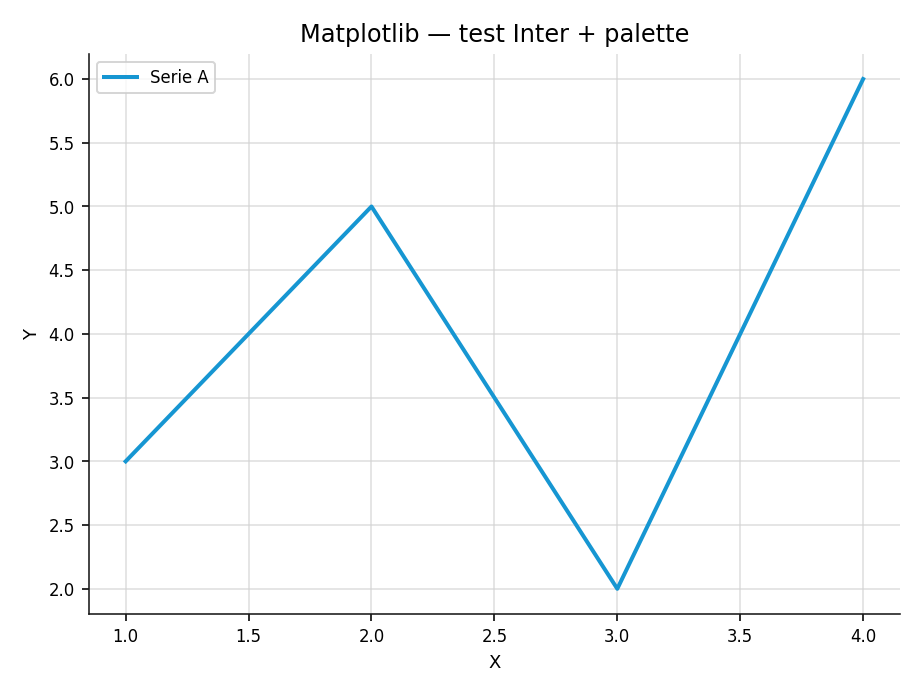

In [3]:
# Test Matplotlib con tema progetto
from builders.matplotlib_builder import apply_mpl_theme
import matplotlib.pyplot as plt
from IPython.display import Image, display

apply_mpl_theme()
plt.figure()
plt.plot([1, 2, 3, 4], [3, 5, 2, 6], label='Serie A')
plt.title('Matplotlib — test Inter + palette')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()
mpl_path = OUT / 'mpl_test.png'
plt.savefig(mpl_path, dpi=144)
plt.close()
print('Salvato:', mpl_path)
display(Image(filename=str(mpl_path)))

In [12]:
# Test Altair con tema + export HTML/PNG
import altair as alt
# Import registra/abilita il tema
from themes.altair_mobility_theme import mobility_theme  # noqa: F401

from vega_datasets import data
# Dati: prova vega_datasets, altrimenti fallback
from vega_datasets import data
# Dati: prova vega_datasets, altrimenti fallback

try:
    cars = data.cars()
except Exception:
    import pandas as pd
    cars = pd.DataFrame({
        'Name': ['Car A','Car B','Car C','Car D','Car E'],
        'Horsepower': [110, 95, 130, 120, 105],
        'Origin': ['USA','Europe','Japan','USA','Europe'],
    })

chart = (
    alt.Chart(cars.head(5))
    .mark_bar()
    .encode(x='Name:N', y='Horsepower:Q', color=alt.Color('Name:N', legend=None))
    .properties(title='Altair — test Inter + palette', width=600, height=300)
)
chart  # display inline

html_path = OUT / 'altair_test.html'
chart.save(html_path)
print('HTML salvato in:', html_path)

chart

HTML salvato in: /Users/dfadda/Git/mobility-book-graphic-style-guide/examples/outputs/altair_test.html


alt.Chart(...)

In [5]:
# Info su font e tokens
import matplotlib as mpl
from design_tokens.design_tokens import TOKENS
print('Matplotlib font family:', mpl.rcParams.get('font.sans-serif'))
print('Text color token:', TOKENS['color']['text'])

Matplotlib font family: ['Inter', 'IBM Plex Sans', 'DejaVu Sans', 'Arial', 'sans-serif']
Text color token: #000000


In [6]:
# Lista file in output
for p in sorted(OUT.iterdir()):
    try:
        size = p.stat().st_size
    except Exception:
        size = '-'
    print(f'- {p.name} (≈ {size} bytes)')

- altair_test.html (≈ 6389 bytes)
- mpl_test.png (≈ 43184 bytes)
